In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv


In [ ]:
Link tổng hợp các bài báo cáo/ nghiên cứu
https://docs.google.com/document/d/1lcOYA7cZFE2UKoTUKJF1JGvXAAc74UfONtuZk0UlKlU/edit?tab=t.0

In [2]:
import pandas as pd

df_air = pd.read_csv("/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv")
df_weather = pd.read_csv("/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv")


In [3]:
df_air.head() 
# 2022 - 08 - 04 - 7:00

,district,city,time,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),carbon_dioxide (ppm),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky ()
0,Ba Dinh,Ha Noi,2022-08-04T00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ba Dinh,Ha Noi,2022-08-04T01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ba Dinh,Ha Noi,2022-08-04T02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ba Dinh,Ha Noi,2022-08-04T03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ba Dinh,Ha Noi,2022-08-04T04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Tiền xử lý dữ liệu
print(df_air.shape)
for col in df_air.columns:
    # print(col)
    cnt = df_air[col].isna().sum()
    rate = cnt/df_air.shape[0]
    print(f"{col} dữ liệu khuyết thiếu {cnt} chiếm tỉ lệ {rate}")

(8189424, 14)
district dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
city dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
time dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
pm10 (μg/m³) dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
pm2_5 (μg/m³) dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
carbon_monoxide (μg/m³) dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
carbon_dioxide (ppm) dữ liệu khuyết thiếu 5217981 chiếm tỉ lệ 0.637160928534168
nitrogen_dioxide (μg/m³) dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
sulphur_dioxide (μg/m³) dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
ozone (μg/m³) dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
aerosol_optical_depth () dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
dust (μg/m³) dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
uv_index () dữ liệu khuyết thiếu 1869 chiếm tỉ lệ 0.00022822117892540427
uv_index_clear_sky () dữ liệu khuyết thiếu 1869 chiếm tỉ 

Carbon_dioxide khuyết nhiều 60% tổng dữ liệu. Song xét đến hệ thống chúng ta đang xây dựng "phân tích chất lượng không khí" và dữ liệu chúng ta đang nhắm đến chủ yếu là dữ liệu ảnh hưởng trực tiếp và nguy hiểm đến sức khỏe như pm10, pm_25, ngoài ra còn một số các trường dữ liệu khác như chỉ số uv.
* Quyết định bỏ cột carbon_dioxide vì thiếu quá nhiều dữ liệu việc sử dụng các phương pháp xử lý giá trị khuyết thiếu như: mean, median, hoặc nội suy có thể ảnh hưởng rất lớn đến độ chính xác thực tế.
* Đối với các cột dữ liệu còn lại tỉ lệ khuyết thiếu rất thấp (0.00022822117892540427) < 3% theo quy chuẩn thông thường ta có thể tiến hành bỏ luôn các hàng có giá trị khuyết thiếu.
* Ta không sử dụng cách điền các giá trị khuyết thiếu bằng mean, median vì dữ liệu khuyết thiếu quá nhỏ việc điền các giá trị khuyết thiếu ít ỏi này có thể ảnh hưởng mô hình dự đoán sau này 

In [25]:
df_op = df_air.drop('carbon_dioxide (ppm)', axis = 1)
df_op = df_op.dropna()
df_op.head()
# df_op.shape

,district,city,time,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky ()
7,Ba Dinh,Ha Noi,2022-08-04 07:00:00,58.0,40.3,595.0,29.7,16.8,24.0,0.43,0.0,0.75,0.80
8,Ba Dinh,Ha Noi,2022-08-04 08:00:00,43.5,30.0,552.0,25.0,18.2,49.0,0.52,0.0,2.10,2.35
9,Ba Dinh,Ha Noi,2022-08-04 09:00:00,47.3,32.7,492.0,18.4,20.2,84.0,0.59,0.0,3.95,4.55
10,Ba Dinh,Ha Noi,2022-08-04 10:00:00,50.3,34.9,429.0,11.2,22.0,128.0,0.68,0.0,4.70,6.75
11,Ba Dinh,Ha Noi,2022-08-04 11:00:00,55.2,38.3,414.0,8.6,21.5,154.0,0.75,0.0,5.10,8.25


In [4]:
df_weather.head()
# 2016 -01 -01 00:00

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),rain (mm),cloud_cover (%),cloud_cover_low (%),...,wind_speed_100m (km/h),wind_direction_10m (°),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
0,Ba Dinh,Ha Noi,2016-01-01T00:00,15.1,80,15.1,0.0,0.0,99,97,...,5.4,347,15.9,16.9,19.8,24.3,0.373,0.375,0.359,0.386
1,Ba Dinh,Ha Noi,2016-01-01T01:00,14.9,82,15.1,0.0,0.0,99,98,...,5.4,353,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
2,Ba Dinh,Ha Noi,2016-01-01T02:00,15.0,81,15.2,0.0,0.0,99,98,...,6.2,360,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
3,Ba Dinh,Ha Noi,2016-01-01T03:00,15.1,76,14.9,0.0,0.0,98,97,...,7.0,8,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
4,Ba Dinh,Ha Noi,2016-01-01T04:00,14.7,78,14.6,0.0,0.0,95,92,...,7.1,14,15.6,16.8,19.8,24.3,0.372,0.374,0.359,0.386


In [18]:
print(df_weather.shape)
for col in df_weather.columns:
    # print(col)
    cnt = df_weather[col].isna().sum()
    rate = cnt/df_weather.shape[0]
    print(f"{col} dữ liệu khuyết thiếu {cnt} chiếm tỉ lệ {rate}")

(23613480, 23)
district dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
city dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
time dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
temperature_2m (°C) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
relative_humidity_2m (%) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
apparent_temperature (°C) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
precipitation (mm) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
rain (mm) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
cloud_cover (%) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
cloud_cover_low (%) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
cloud_cover_mid (%) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
cloud_cover_high (%) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
wind_speed_10m (km/h) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
wind_speed_100m (km/h) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
wind_direction_10m (°) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
soil_temperature_0_to_7cm (°C) dữ liệu khuyết thiếu 0 chiếm tỉ lệ 0.0
soil_temperature_7_to_28cm (°C) dữ liệu khuyết thiếu 0 chiếm tỉ lệ

Dữ liệu thời tiết hoàn hảo không thiếu không cần tiền xử lý gì cả

In [27]:
import pandas as pd

# df_air['time'] = pd.to_datetime(df_air['time'])
df_op['time'] = pd.to_datetime(df_op['time'])
df_weather['time'] = pd.to_datetime(df_weather['time'])
# Lọc toàn bộ dữ liệu trong ngày 30/10/2025
# day_filter = df1[df1['time'].dt.date == pd.to_datetime("2025-10-30").date()]

start_time = "2025-01-01 07:00:00"
end_time = "2026-01-01 07:00:00"
district = "Thanh Xuan"
# df_a = df_air[(df_air['time'] >= start_time) & (df_air['time'] <= end_time) & (df_air['district'] == district)]
df_a = df_op[(df_op['time'] >= start_time) & (df_op['time'] <= end_time) & (df_op['district'] == district)]
df_w = df_weather[(df_weather['time'] >= start_time) & (df_weather['time'] <= end_time) & (df_weather['district'] == district)]
# df_a = df_a[['district',	'city'	,'time',	'pm10 (μg/m³)',	'pm2_5 (μg/m³)']]

In [28]:
df_a.head()

,district,city,time,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky ()
235855,Thanh Xuan,Ha Noi,2025-01-01 07:00:00,183.0,182.5,1770.0,63.8,61.4,7.0,0.83,0.0,0.10,0.10
235856,Thanh Xuan,Ha Noi,2025-01-01 08:00:00,174.6,174.6,1710.0,59.2,64.7,25.0,0.82,0.0,0.65,0.65
235857,Thanh Xuan,Ha Noi,2025-01-01 09:00:00,135.5,135.5,1532.0,52.6,69.0,51.0,0.81,0.0,1.80,1.80
235858,Thanh Xuan,Ha Noi,2025-01-01 10:00:00,111.8,111.5,1362.0,44.9,70.1,80.0,0.81,0.0,3.20,3.20
235859,Thanh Xuan,Ha Noi,2025-01-01 11:00:00,92.2,92.2,1236.0,35.1,64.8,112.0,0.80,0.0,4.35,4.35


In [29]:
df_w.head()

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),rain (mm),cloud_cover (%),cloud_cover_low (%),...,wind_speed_100m (km/h),wind_direction_10m (°),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
697999,Thanh Xuan,Ha Noi,2025-01-01 07:00:00,13.0,96,12.9,0.0,0.0,0,0,...,13.0,316,14.6,20.4,22.4,25.7,0.066,0.128,0.136,0.303
698000,Thanh Xuan,Ha Noi,2025-01-01 08:00:00,14.3,93,14.6,0.0,0.0,10,10,...,11.8,331,16.1,20.2,22.4,25.7,0.063,0.128,0.133,0.303
698001,Thanh Xuan,Ha Noi,2025-01-01 09:00:00,17.2,75,17.5,0.0,0.0,0,0,...,7.2,334,17.5,20.1,22.4,25.7,0.063,0.128,0.133,0.303
698002,Thanh Xuan,Ha Noi,2025-01-01 10:00:00,19.8,62,19.8,0.0,0.0,0,0,...,6.3,340,19.8,20.1,22.4,25.7,0.063,0.128,0.134,0.303
698003,Thanh Xuan,Ha Noi,2025-01-01 11:00:00,21.7,51,22.0,0.0,0.0,0,0,...,4.0,350,22.4,20.2,22.4,25.7,0.063,0.128,0.134,0.303


In [30]:
# Tập dữ liệu bao gồm chất lượng không khí và thời tiết theo từng giờ trong năm 2025
result = pd.merge(df_a, df_w, on ="time", how="inner")

result.to_csv("result1.csv", index = False)

In [35]:
# print(result.head())
result.head()
# result.shape[0]

,district_x,city_x,time,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),...,wind_speed_100m (km/h),wind_direction_10m (°),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
0,Thanh Xuan,Ha Noi,2025-01-01 07:00:00,183.0,182.5,1770.0,63.8,61.4,7.0,0.83,...,13.0,316,14.6,20.4,22.4,25.7,0.066,0.128,0.136,0.303
1,Thanh Xuan,Ha Noi,2025-01-01 08:00:00,174.6,174.6,1710.0,59.2,64.7,25.0,0.82,...,11.8,331,16.1,20.2,22.4,25.7,0.063,0.128,0.133,0.303
2,Thanh Xuan,Ha Noi,2025-01-01 09:00:00,135.5,135.5,1532.0,52.6,69.0,51.0,0.81,...,7.2,334,17.5,20.1,22.4,25.7,0.063,0.128,0.133,0.303
3,Thanh Xuan,Ha Noi,2025-01-01 10:00:00,111.8,111.5,1362.0,44.9,70.1,80.0,0.81,...,6.3,340,19.8,20.1,22.4,25.7,0.063,0.128,0.134,0.303
4,Thanh Xuan,Ha Noi,2025-01-01 11:00:00,92.2,92.2,1236.0,35.1,64.8,112.0,0.80,...,4.0,350,22.4,20.2,22.4,25.7,0.063,0.128,0.134,0.303


In [53]:
import matplotlib.pyplot as plt


def visualization(xdf, ydf, xl, yl, title):
    # Vẽ biểu đồ
    plt.figure()
    plt.scatter(xdf, ydf)
    # Nhãn
    plt.xlabel(xl)
    plt.ylabel(yl)
    plt.title(title)
    plt.show()

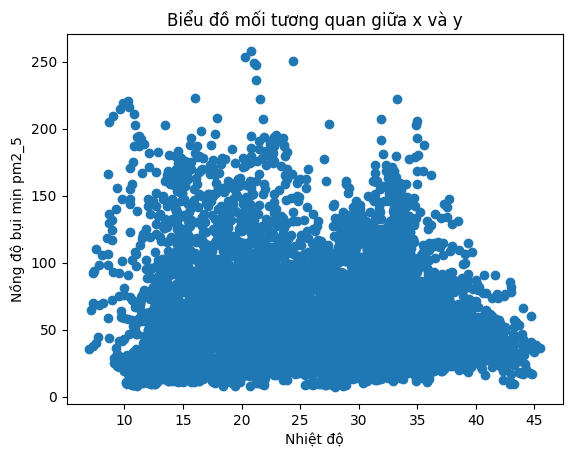

In [54]:
df = result
ydf = df['pm2_5 (μg/m³)']
xdf = df['apparent_temperature (°C)']
xl = 'Nhiệt độ'
yl = 'Nồng độ bụi mịn pm2_5'
title = 'Biểu đồ mối tương quan giữa x và y'
visualization(xdf,ydf,xl,yl,title)

Nhiệt độ có mối quan hệ không đồng nhất với nồng độ bụi mịn. Sự tăng giảm của nhiệt độ không có một quy luật nhất quán nào liên quan đến nồng độ bụi mịn.

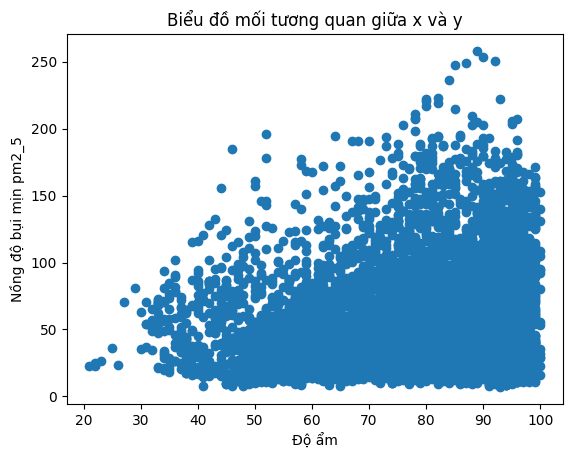

In [55]:
df = result
xdf = df['relative_humidity_2m (%)']
ydf = df['pm2_5 (μg/m³)']
xl = 'Độ ẩm'
yl = 'Nồng độ bụi mịn pm2_5'
title = 'Biểu đồ mối tương quan giữa x và y'
visualization(xdf,ydf,xl,yl,title)

Độ ẩm có xu hướng tăng nhẹ, khi độ ẩm tăng lên giới hạn trên của nồng độ bụi mịn PM2.5 cũng có xu hướng cao dần.  
Ở mức độ ẩm thấp (khoảng 20% - 40%), nồng độ PM2.5 khá thấp và ổn định, chủ yếu dưới 100.  
Ở mức độ ẩm cao (trên 70%), nồng độ PM2.5 biến động cực kỳ mạnh, xuất hiện nhiều điểm đạt ngưỡng rất cao (trên 200).  
Dữ liệu cho thấy sự phân tán cực lớn khi độ ẩm cao. Điều này có nghĩa là độ ẩm không phải là yếu tố duy nhất quyết định nồng độ bụi. Dù độ ẩm ở mức 90%, vẫn có những thời điểm PM2.5 rất thấp và ngược lại.  
Khi độ ẩm cao, hơi nước có thể bám vào các hạt bụi mịn, làm chúng tăng kích thước và khối lượng, đôi khi tạo thành sương mù quang hóa, giữ bụi ở tầng thấp gần mặt đất.  
Độ ẩm cao thường đi kèm với điều kiện khí quyển ổn định hoặc nghịch nhiệt, ngăn cản sự phát tán của bụi mịn vào không trung từ đó làm tăng nồng độ bụi mịn tại một khu vực  

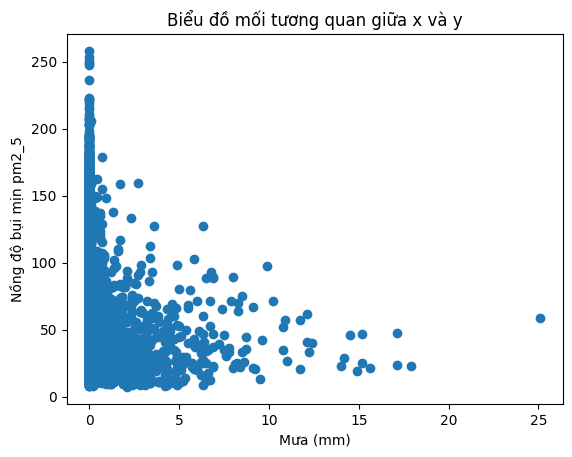

In [57]:
df = result
xdf = df['rain (mm)']
ydf = df['pm2_5 (μg/m³)']
xl = 'Mưa (mm)'
yl = 'Nồng độ bụi mịn pm2_5'
title = 'Biểu đồ mối tương quan giữa x và y'
visualization(xdf,ydf,xl,yl,title)

Nồng độ bụi mịn chỉ có thể lớn hoặc cao tại 0mm và sẽ giảm xuống rất nhiều nếu có mưa.  
Mưa ảnh hưởng rất lớn đến nồng độ bụi mịn trong không khí, chỉ cần một cơn mưa nồng độ bụi mịn trong không khí có thể giảm mạnh, chỉ cần lượng mưa khoảng vài mm cũng có thể khiến nồng độ bụi mịn trong không khí giảm rõ rệt


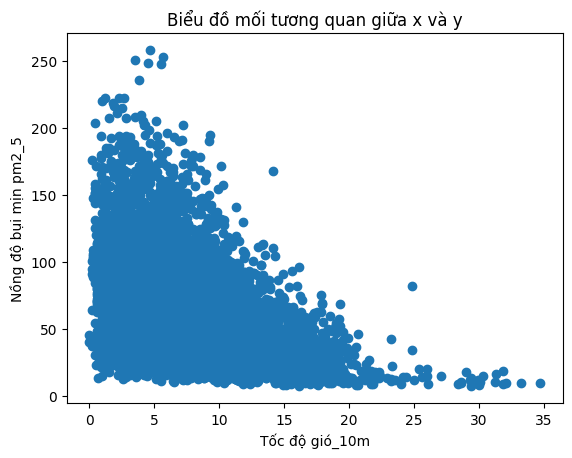

In [58]:
df = result
xdf = df['wind_speed_10m (km/h)']
ydf = df['pm2_5 (μg/m³)']
xl = 'Tốc độ gió_10m'
yl = 'Nồng độ bụi mịn pm2_5'
title = 'Biểu đồ mối tương quan giữa x và y'
visualization(xdf,ydf,xl,yl,title)

Khi tốc độ gió tăng lên, nồng độ bụi mịn PM2.5 có xu hướng giảm xuống nhanh chóng.  
Dữ liệu tạo thành hình dáng giống một cái phễu nằm ngang. Ở tốc độ gió thấp, dải giá trị của PM2.5 rất rộng (từ gần 0 đến hơn 250). Khi tốc độ gió vượt quá 15-20 m/s, nồng độ bụi mịn bị "nén" lại ở mức rất thấp (thường dưới 50).  
Ta có thể lý giải đơn giản như sau: Khi tốc độ gió lớn nó sẽ làm phân tán các hạt bụi trong không khí đi xa khỏi tác nhân ô nhiễm, nguồn phát thải cục bộ  
Khi tốc độ gió bằng 0 không khí bị đình trệ, khiến bụi mịn tích tụ lại một chỗ, dẫn đến các đợt ô nhiễm nghiêm trọng.
Ngoài ra các cơn mưa giông to thường đi kèm gió mà mưa chính là một tác nhân rất lớn ảnh hưởng đến nồng độ bụi mịn

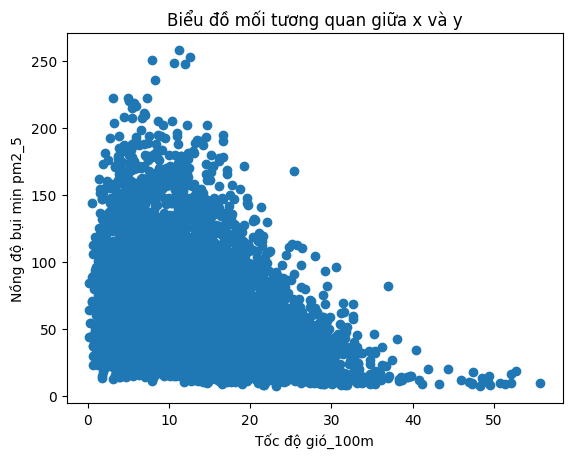

In [59]:
df = result
xdf = df['wind_speed_100m (km/h)']
ydf = df['pm2_5 (μg/m³)']
xl = 'Tốc độ gió_100m'
yl = 'Nồng độ bụi mịn pm2_5'
title = 'Biểu đồ mối tương quan giữa x và y'
visualization(xdf,ydf,xl,yl,title)

Cũng giống như biểu đồ gió ở độ cao 10m

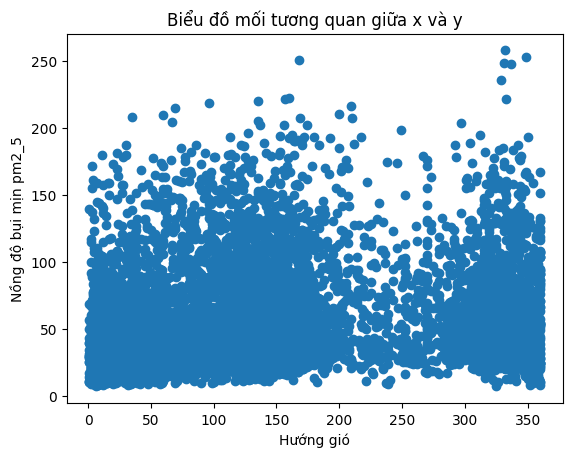

In [60]:
df = result
xdf = df['wind_direction_10m (°)']
ydf = df['pm2_5 (μg/m³)']
xl = 'Hướng gió'
yl = 'Nồng độ bụi mịn pm2_5'
title = 'Biểu đồ mối tương quan giữa x và y'
visualization(xdf,ydf,xl,yl,title)

Không có sự tương quan rõ rệt nào giữa hướng gió và nồng độ bụi mịn nhưng nhìn kỹ vào các đỉnh cao nhất của PM2.5, chúng ta thấy nồng độ bụi không phân bố đều mà tập trung cao hơn ở một số cung hướng nhất định.  
Vùng ô nhiễm cao nhất (300-350): Đây là khu vực có các điểm dữ liệu vọt lên cao nhất (đạt ngưỡng gần 260). Điều này gợi ý rằng luồng gió thổi từ hướng Tây Bắc - Bắc có thể đang mang theo bụi mịn từ các nguồn thải lớn hoặc khu vực lân cận vào vị trí đo.
Vùng ô nhiễm thứ cấp (150-200): Có một cụm đỉnh cao khác quanh mức 170 (hướng Nam).  
Vùng tương đối thấp (230-280): Ở khoảng hướng Tây - Tây Nam, các đỉnh của cột PM2.5 có vẻ thấp hơn so với hai vùng trên, cho thấy gió từ hướng này có thể sạch hơn hoặc ít đi qua nguồn phát thải.
Ta có thể lý giải những hướng gió khác nhau có thể xuất phát từ mùa khác nhau mà mùa lại là nguyên nhân của sự thay đổi nhiệt độ độ ẩm, tốc độ gió,...  
Do địa hình khu vực riêng đồi núi, đồng bằng dẫn đến hướng gió sẽ mang theo bụi đến hoặc khuếch tán bụi ra khỏi khu vực đó, Do những nguồn tác nhân phát thải nằm tại hướng gió đó.